In [1]:
# Reads in FITS files from the MCT and checks them

In [1]:
from astropy.io import fits
import numpy as np
import glob
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
stem = '/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/'

In [3]:
file_name_list = glob.glob(stem + '*.fits')

In [4]:
file_name_list

['/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317161526_R01_M01_N01.fits',
 '/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165058_R01_M01_N01.fits',
 '/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165250_R01_M01_N01.fits',
 '/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317161516_R01_M01_N01.fits',
 '/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165304_R01_M01_N01.fits',
 '/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317161153_R01_M01_N01.fits',
 '/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165257_R01_M01_N01.fits',
 '/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165511_R01_M01_N01.fits',
 '/Users/eckhartspalding/Documen

(2048, 2048)


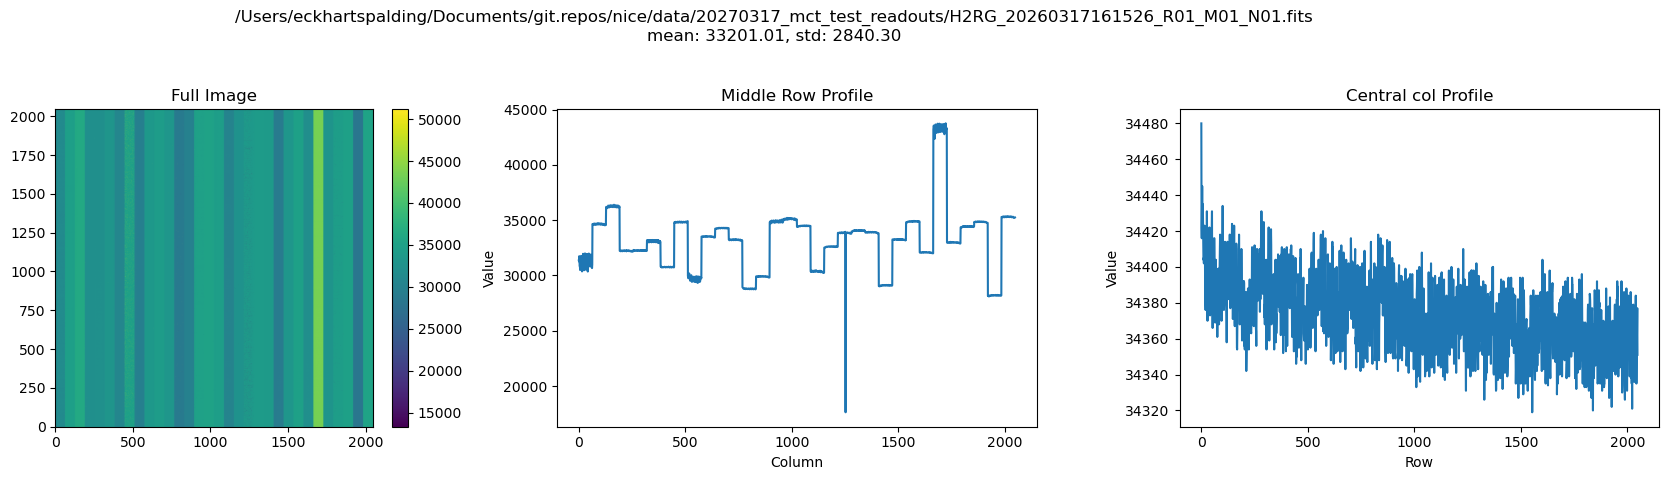

(2048, 2048)


<Figure size 640x480 with 0 Axes>

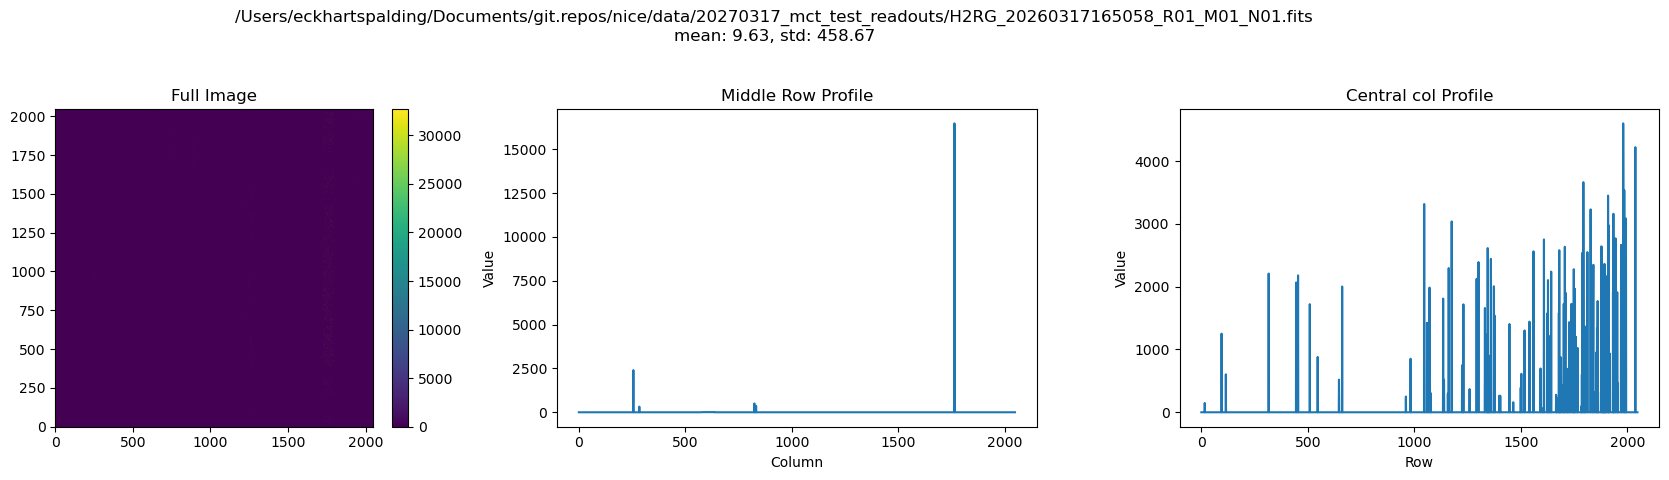

(2048, 2048)


<Figure size 640x480 with 0 Axes>

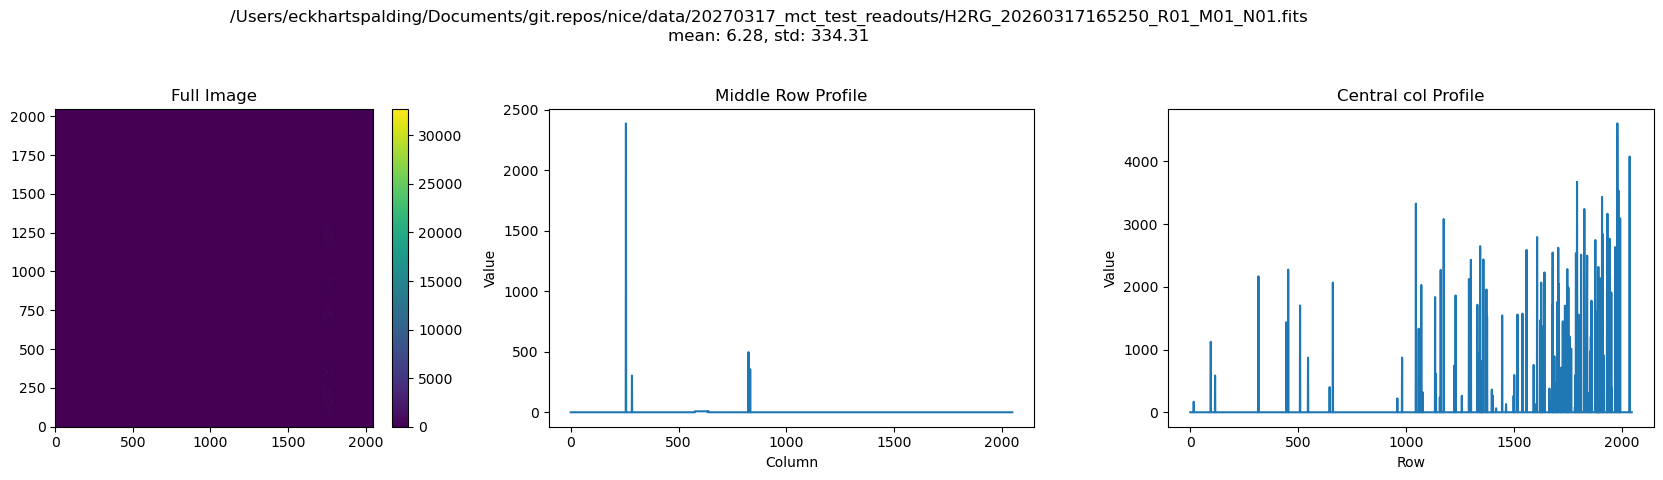

(2048, 2048)


<Figure size 640x480 with 0 Axes>

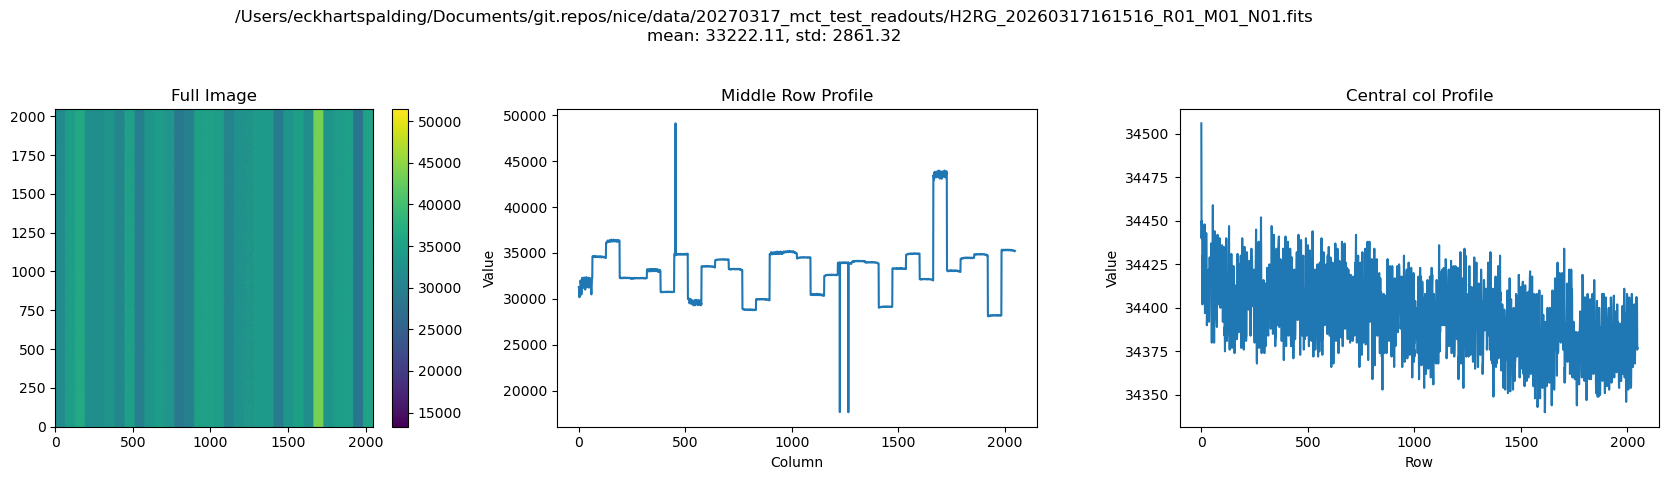

(2048, 2048)


<Figure size 640x480 with 0 Axes>

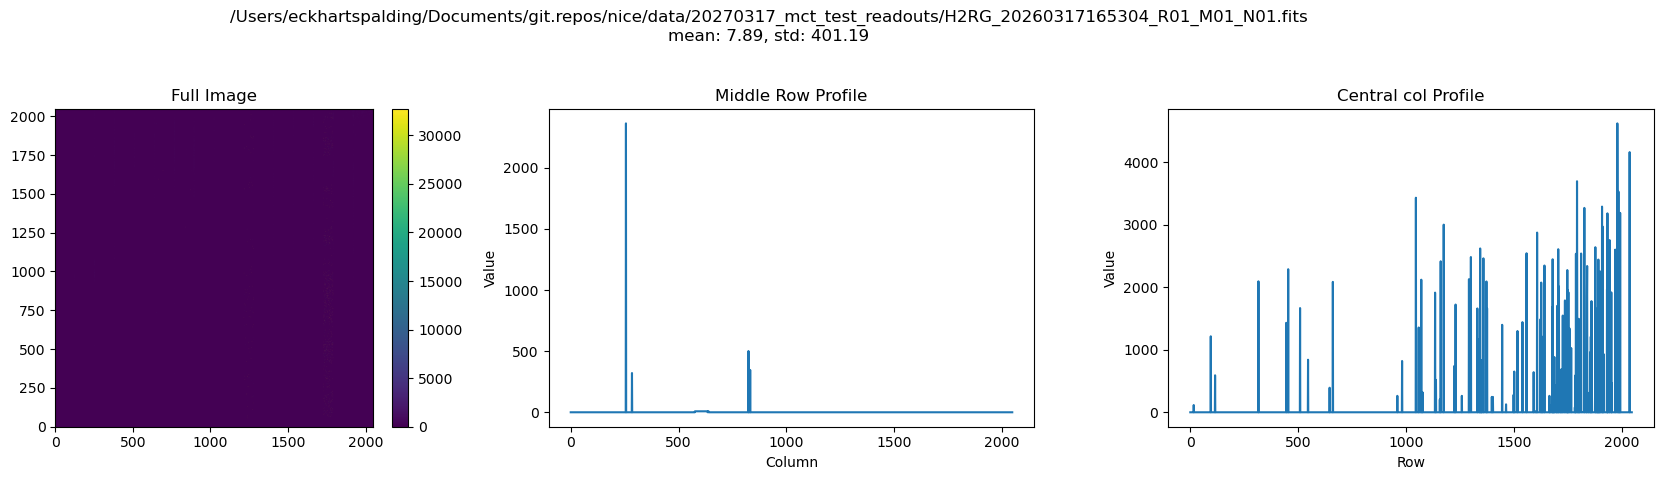

(2048, 2048)


<Figure size 640x480 with 0 Axes>

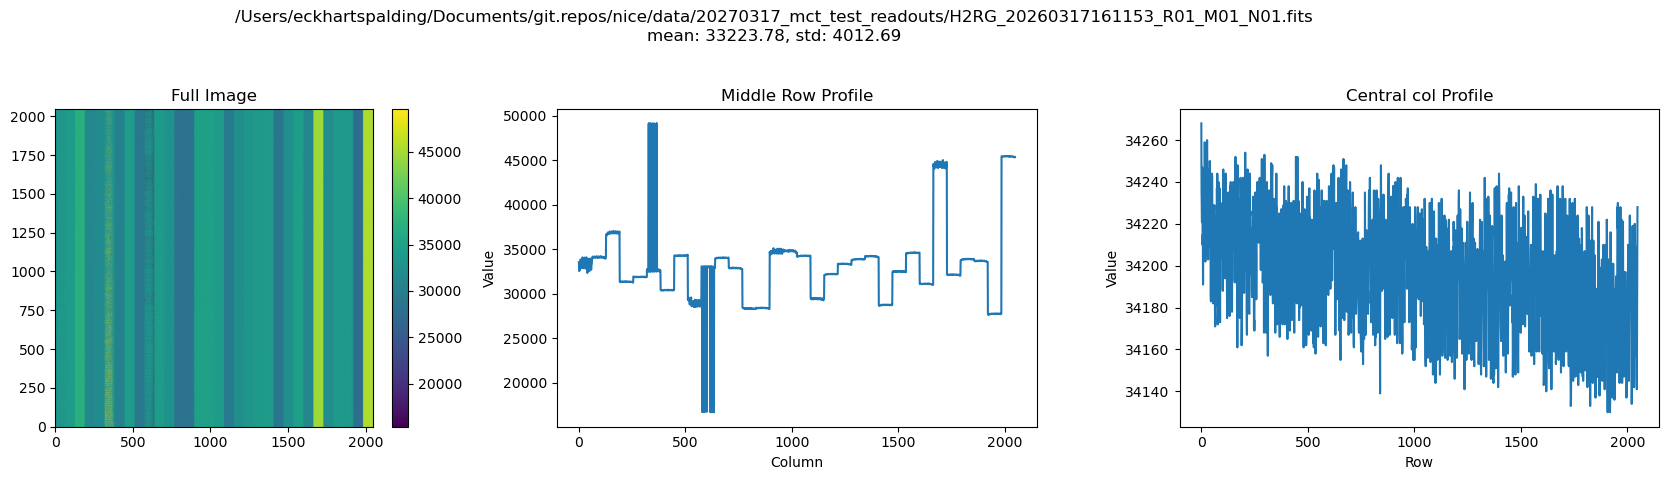

(2048, 2048)


<Figure size 640x480 with 0 Axes>

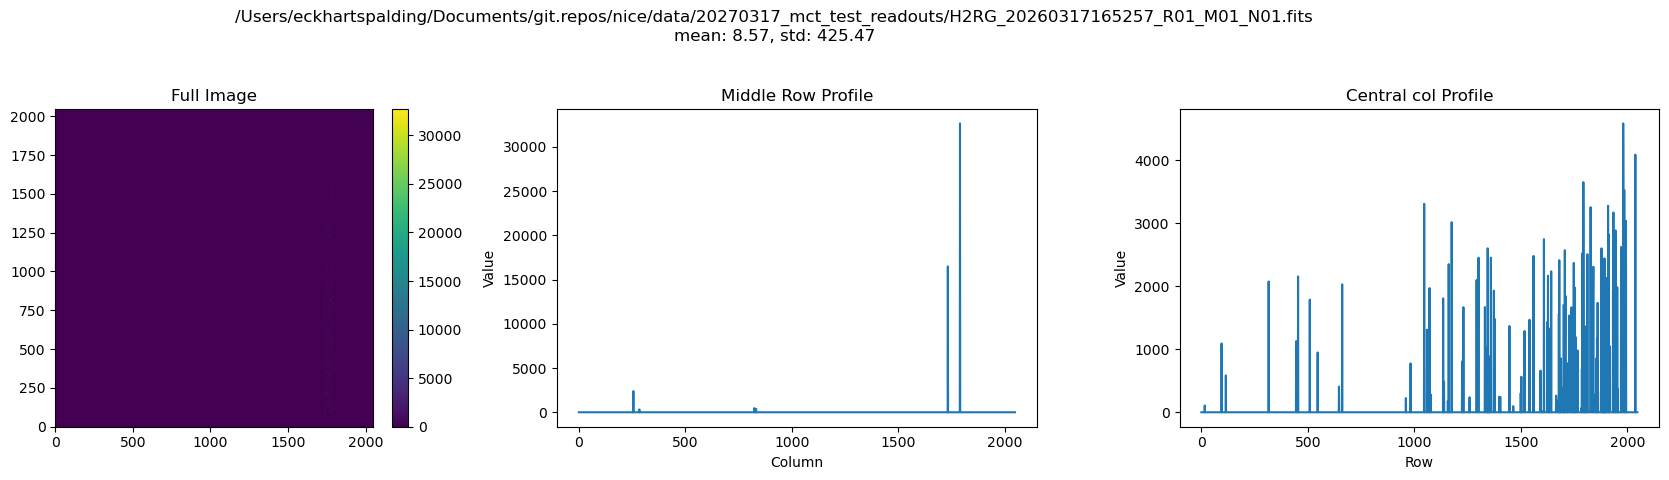

(2048, 2048)


<Figure size 640x480 with 0 Axes>

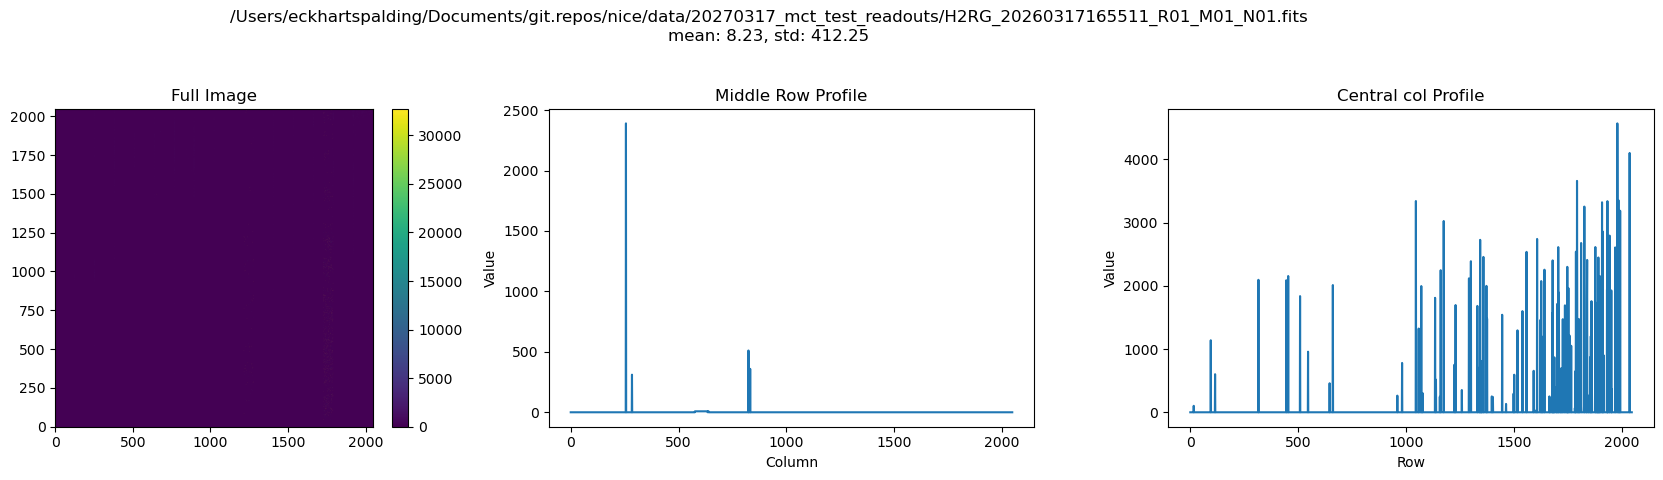

(2048, 2048)


<Figure size 640x480 with 0 Axes>

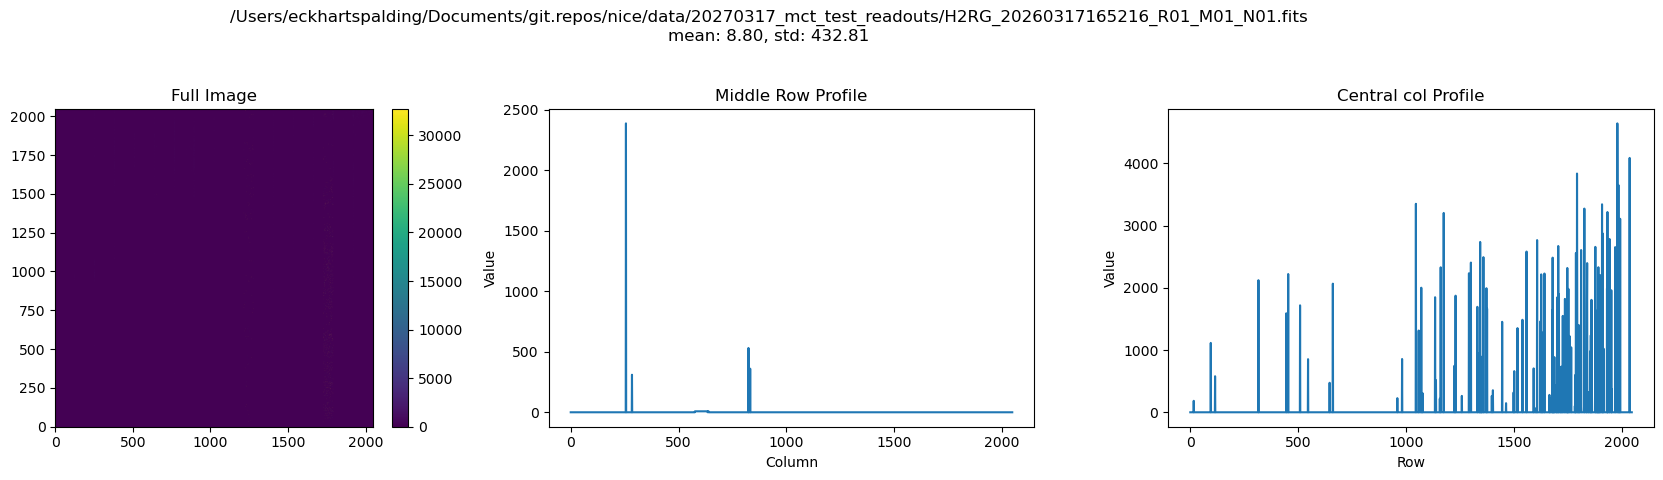

(2048, 2048)


<Figure size 640x480 with 0 Axes>

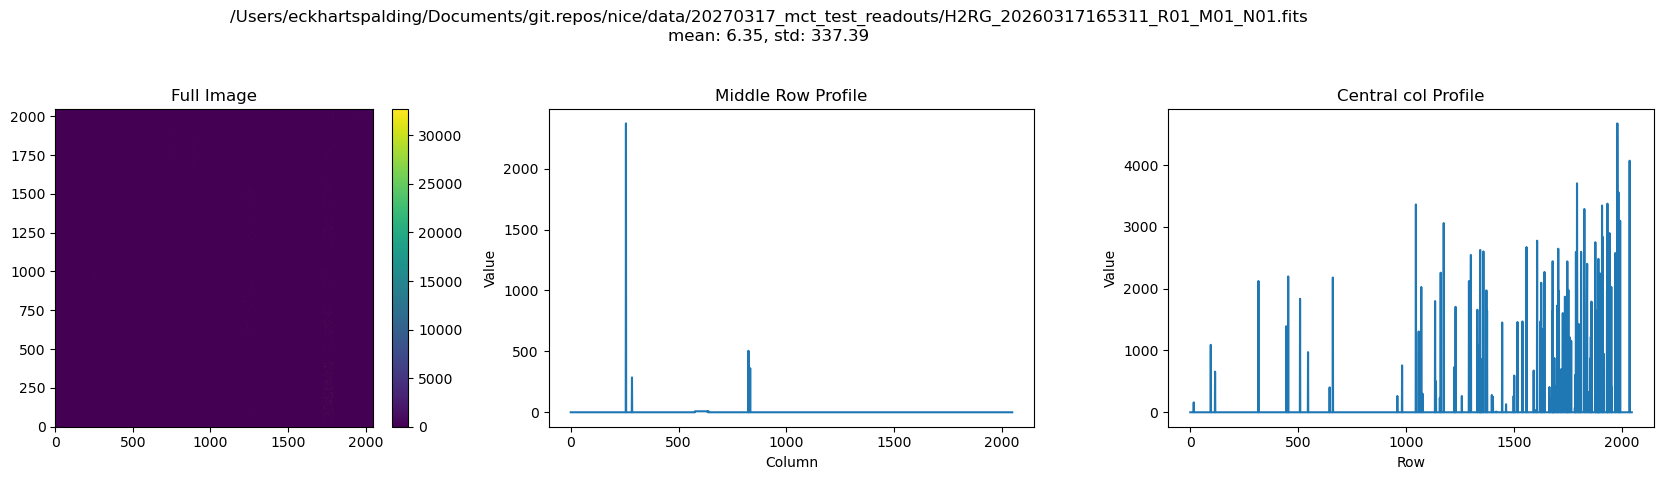

(2048, 2048)


<Figure size 640x480 with 0 Axes>

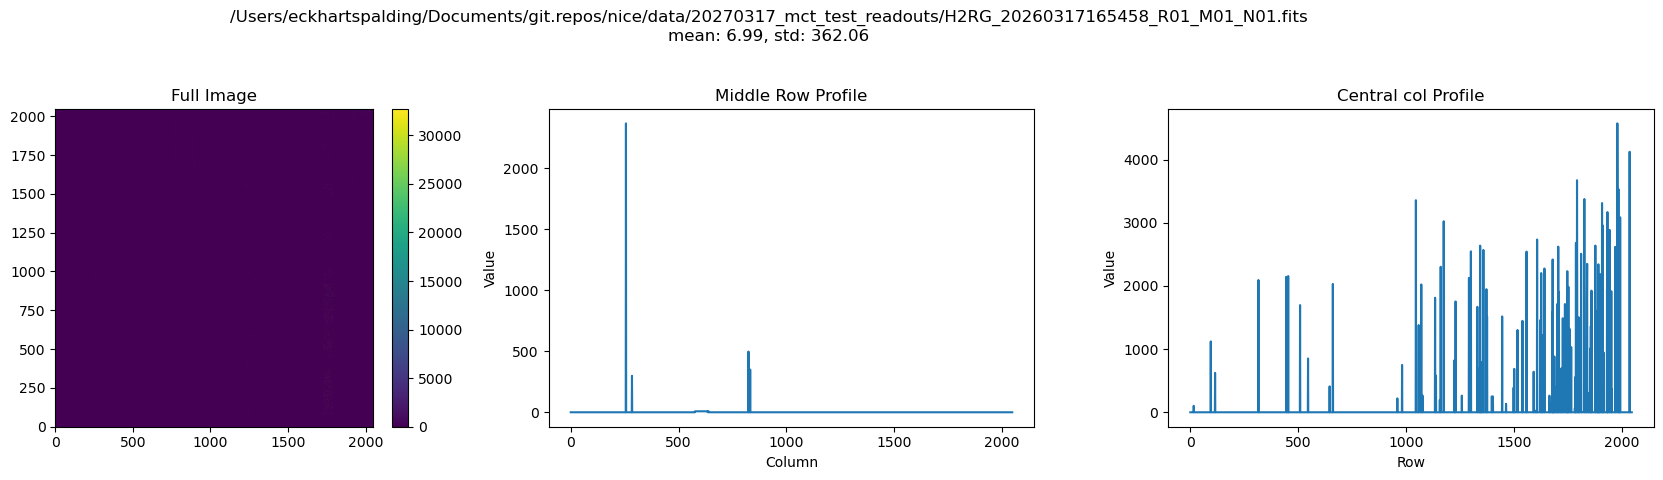

(2048, 2048)


<Figure size 640x480 with 0 Axes>

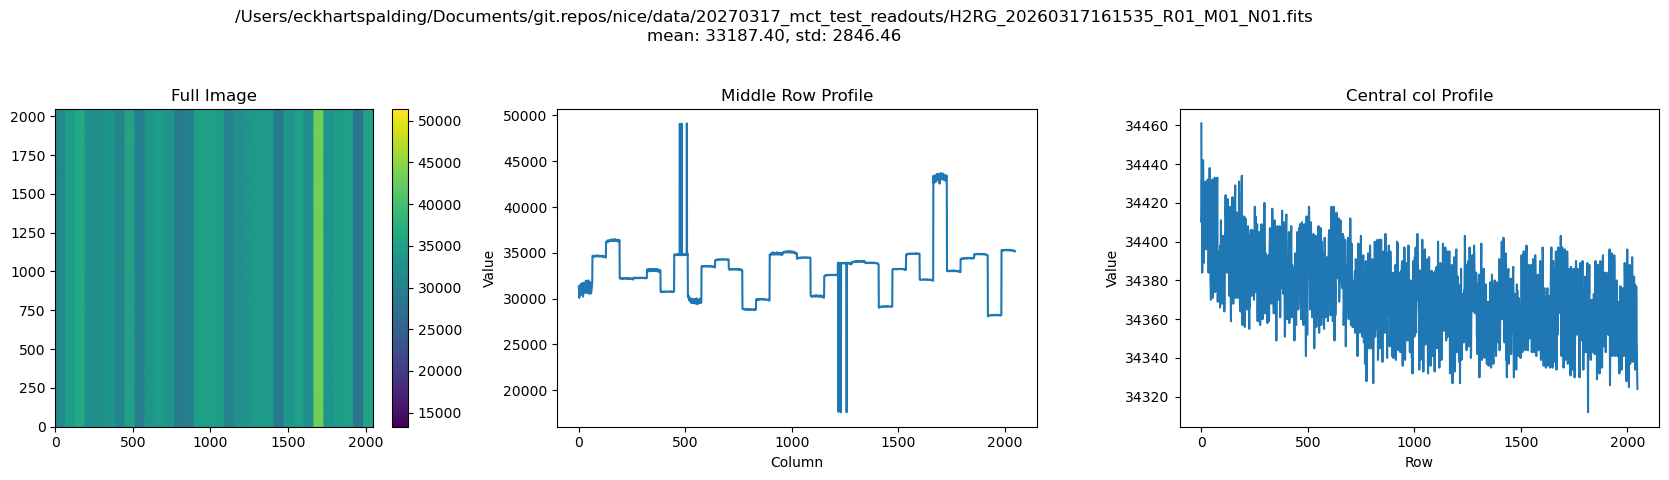

(2048, 2048)


<Figure size 640x480 with 0 Axes>

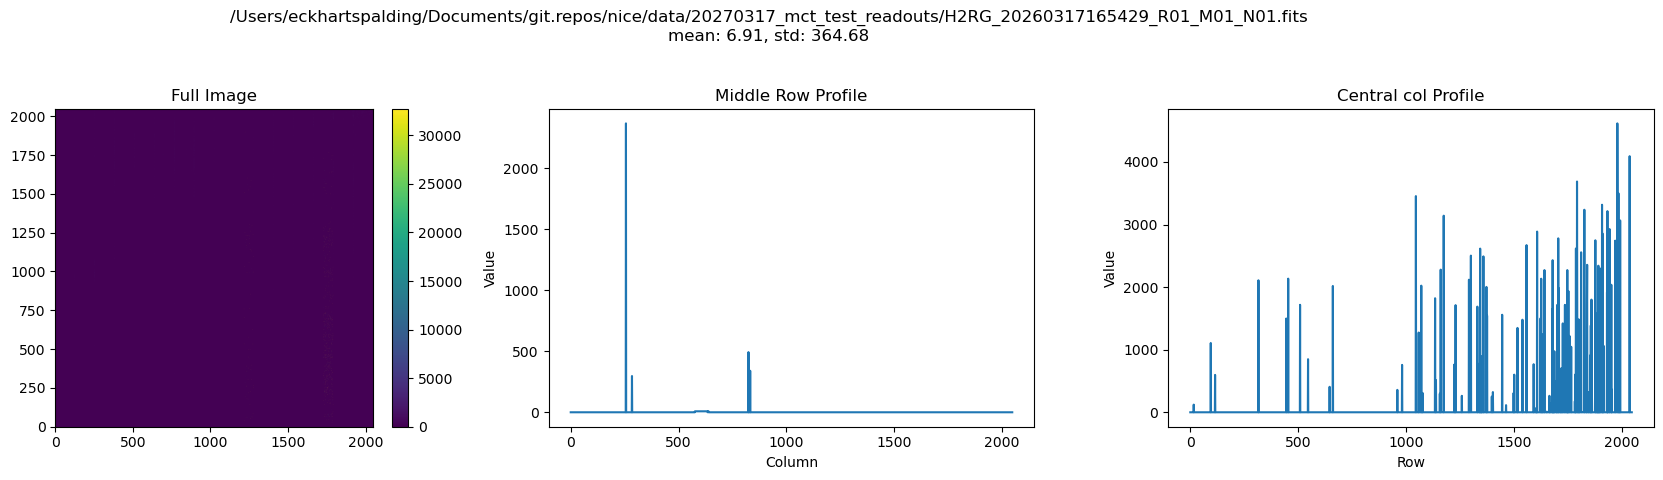

(2048, 2048)


<Figure size 640x480 with 0 Axes>

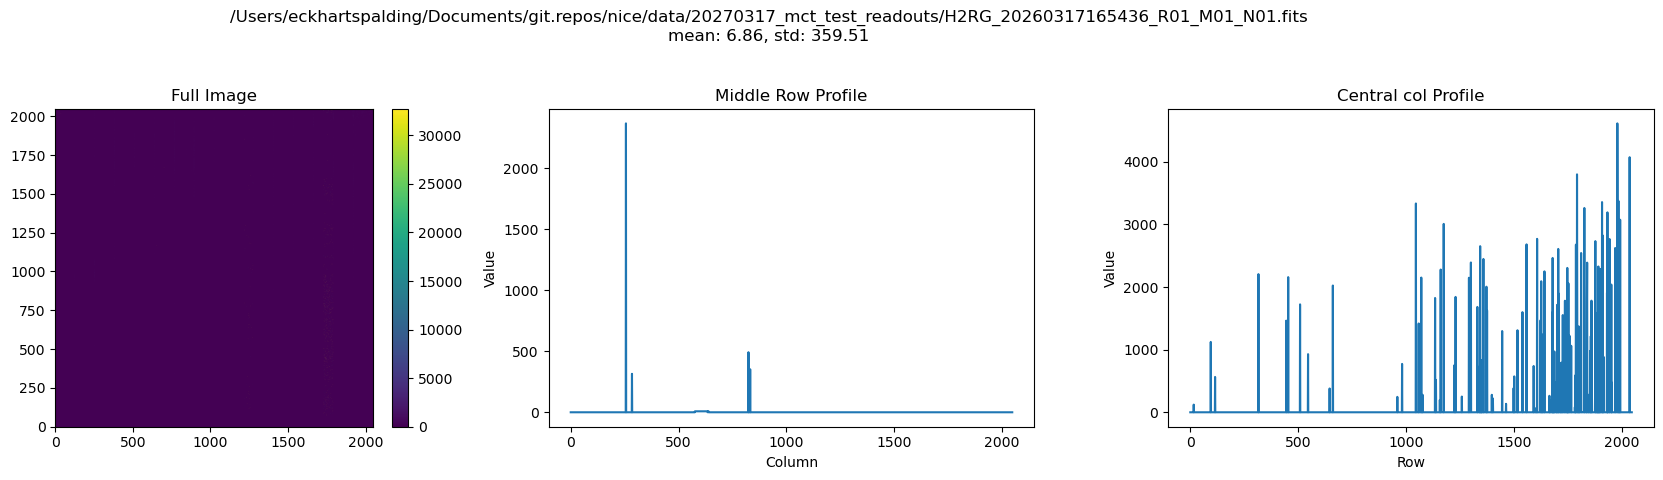

<Figure size 640x480 with 0 Axes>

In [ ]:
file_name_num = 0
for file_name in file_name_list:

    hdul = fits.open(file_name)
    data = hdul[0].data
    print(data.shape)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # First subplot: show the full image
    im0 = axs[0].imshow(data, origin='lower')
    axs[0].set_title('Full Image')
    fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    
    middle_row = data[data.shape[0] // 2, :]
    axs[1].plot(middle_row)
    axs[1].set_title('Middle Row Profile')
    axs[1].set_xlabel('Column')
    axs[1].set_ylabel('Value')

    central_col = data[:, data.shape[0] // 2]
    axs[2].plot(central_col)
    axs[2].set_title('Central col Profile')
    axs[2].set_xlabel('Row')
    axs[2].set_ylabel('Value')
    
    fig.suptitle(f"{file_name}\nmean: {np.mean(data):.2f}, std: {np.std(data):.2f}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    file_name_plot = f'junk_{file_name_num:02d}.png'
    plt.savefig(file_name_plot)
    plt.clf()
    file_name_num += 1


In [11]:

print(data.shape)
#plt.imshow(data, origin='lower')
#plt.show()

width_col = 64
n_cols = 32

# loop over the files
for file_name_num in range(0, len(file_name_list)):
    file_name = file_name_list[file_name_num]
    print(file_name)

    hdul = fits.open(file_name)
    frame_data = hdul[0].data

    # loop over each of the vertical readouts column, and subtract the median of that column
    for col_num in range(0, n_cols):
        idx1, idx2 = width_col*col_num, width_col*(col_num+1)
        col_data = frame_data[:, idx1:idx2]
        median_val = np.median(col_data)
        frame_data[:, idx1:idx2] = col_data - median_val
        #frame_data[:, idx1:idx2] = 0

        #print(col_num)
        #print(median_val)
        #print('--------------------------------')

        # plot the result
        #plt.imshow(frame_data, origin='lower')
        #plt.show()
    
    file_name_plot = 'frame_hot_' + str(file_name_num) + '.png'

    idx_hot = frame_data > np.std(frame_data)
    idx_normal = frame_data <= np.std(frame_data)
    pix_map = np.zeros_like(frame_data)
    # Compute a threshold for "hot" pixels using a robust statistic
    threshold = np.median(frame_data) + 5 * np.std(frame_data)
    pix_map = np.zeros_like(frame_data, dtype=np.uint8)
    pix_map[frame_data > threshold] = 0
    pix_map[frame_data < threshold] = 1

    plt.figure(figsize=(5, 5))
    plt.imshow(pix_map, origin='lower', cmap='gray')
    plt.title(f"Hot Pixel Map: {file_name_num}")
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(file_name_plot, dpi=150)
    plt.close()
    print(f'Wrote {file_name_plot} ({np.sum(pix_map)} hot pixels)')



    '''
    file_name_plot = 'frame_data_' + str(file_name_num) + '.png'
    plt.figure(figsize=(5, 5))
    plt.imshow(frame_data, origin='lower')
    plt.savefig(file_name_plot)
    plt.clf()
    print('Wrote ' + file_name_plot)
    '''


(2048, 2048)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317161526_R01_M01_N01.fits
Wrote frame_hot_0.png (4194304 hot pixels)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165058_R01_M01_N01.fits
Wrote frame_hot_1.png (4187421 hot pixels)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165250_R01_M01_N01.fits
Wrote frame_hot_2.png (4186198 hot pixels)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317161516_R01_M01_N01.fits
Wrote frame_hot_3.png (4194304 hot pixels)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317165304_R01_M01_N01.fits
Wrote frame_hot_4.png (4186419 hot pixels)
/Users/eckhartspalding/Documents/git.repos/nice/data/20270317_mct_test_readouts/H2RG_20260317161153_R01_M01_N01.fits
Wrote frame_hot_5.png (4194304 hot pixels)
/Users/eckhartspalding/Docu

In [ ]:
print(2048/32)

64.0
